In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score # y가 없어... 그래도 해결해야 하니까 통계치를 기반으로 모델을 평가해주는 방법을 써서 해보려고 합니다...

## Q1. dbscan.csv 파일을 Pandas를 사용해서 읽고 인덱스를 날짜 타입으로 변환하세요

- 시계열 데이터는 반드시 날짜를 인덱스로 만들자

In [61]:
df = pd.read_csv('data/dbscan.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1227 non-null   object 
 1   KOSPI        1227 non-null   float64
 2   S&P 500      1185 non-null   float64
 3   Gold         1187 non-null   float64
 4   Oil(WTI)     1187 non-null   float64
 5   US 10Y Bond  1188 non-null   float64
 6   KRW/USD      1225 non-null   float64
 7   JPY/USD      1225 non-null   float64
dtypes: float64(7), object(1)
memory usage: 76.8+ KB


In [62]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1227 non-null   datetime64[ns]
 1   KOSPI        1227 non-null   float64       
 2   S&P 500      1185 non-null   float64       
 3   Gold         1187 non-null   float64       
 4   Oil(WTI)     1187 non-null   float64       
 5   US 10Y Bond  1188 non-null   float64       
 6   KRW/USD      1225 non-null   float64       
 7   JPY/USD      1225 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 76.8 KB


- 독립변인(x축)이 날짜면 시계열 데이터
- 날짜 데이터는 꼭 datetime으로 변환하기!!!

In [63]:
df = df.set_index(keys='Date')
df.head()

,KOSPI,S&P 500,Gold,Oil(WTI),US 10Y Bond,KRW/USD,JPY/USD
Date,,,,,,,
2020-05-15,1927.280029,2863.699951,1753.400024,29.430000,139.328125,1225.459961,107.364998
2020-05-18,1937.109985,2953.909912,1731.800049,31.820000,138.593750,1232.089966,107.208000
2020-05-19,1980.609985,2922.939941,1744.199951,32.500000,138.859375,1224.199951,107.380997
2020-05-20,1989.640015,2971.610107,1750.599976,33.490002,139.078125,1224.319946,107.809998
2020-05-21,1998.310059,2948.510010,1720.500000,33.919998,139.062500,1226.550049,107.591003


## Q2. 결측치가 몇 개인지 확인하고, 선형 보간법 또는 채우기 기법(ffill, bfill)을 사용해서 결측치를 처리하세요.

In [64]:
df.isnull().sum()

KOSPI           0
S&P 500        42
Gold           40
Oil(WTI)       40
US 10Y Bond    39
KRW/USD         2
JPY/USD         2
dtype: int64

- 첫 번째 방법

In [65]:
df = df.interpolate() # 결측치 보간 / method='linear' 해당 기울기를 이용해서 빈 칸 채우는 것 / 향후 5년 간 크게 꺾이지 않는 한 사용
df.isnull().sum()

KOSPI          0
S&P 500        0
Gold           0
Oil(WTI)       0
US 10Y Bond    0
KRW/USD        0
JPY/USD        0
dtype: int64

- 두 번째 방법

In [66]:
# df = df.ffill() # 앞의 데이터를 가져와서 채움, 변화가 없을 것이라 가정하는 것
# df.isnull().sum()

## 3. 이상치를 찾아보세요.

In [67]:
def remove_outliers(data, threshold=3):
    z_score = stats.zscore(data)
    abs_z_score = np.abs(z_score) # 절대값 (*양수가 되면 안 되는 값이 있을 때는 하면 큰일남)
    filtered_entries = (abs_z_score < threshold).all(axis=1) # abs_z_score < 3 : 일반적으로 3을 넘어가면 데이터가 뽀족한거임
    return df[filtered_entries]

In [68]:
df_no_outliers = remove_outliers(df)
df_no_outliers.shape

(1204, 7)

In [69]:
returns = np.log(df_no_outliers / df_no_outliers.shift(1)).dropna() # shift(1) : 비트코인 주식 예상하는 가장 쉬운 방법 / 시계열 데이터 다룰 때 아주 중요함 / 차분값
returns # 수익률로 바꿈
# np.log : 1.xxx 일 때 상관관계가 좀 높게 나올 수 있어서 작게 표현해주는 거임 (아마도)

,KOSPI,S&P 500,Gold,Oil(WTI),US 10Y Bond,KRW/USD,JPY/USD
Date,,,,,,,
2020-05-18,0.005087,0.031015,-0.012395,0.078080,-0.005285,0.005396,-0.001463
2020-05-19,0.022208,-0.010540,0.007135,0.021145,0.001915,-0.006424,0.001612
2020-05-20,0.004549,0.016514,0.003663,0.030007,0.001574,0.000098,0.003987
2020-05-21,0.004348,-0.007804,-0.017344,0.012758,-0.000112,0.001820,-0.002033
2020-05-22,-0.014202,0.002351,0.008162,-0.019950,0.000674,0.005561,0.000372
...,...,...,...,...,...,...,...
2025-04-03,-0.007676,-0.049606,-0.013757,-0.068684,0.010178,-0.002677,-0.012841
2025-04-04,-0.008594,-0.061609,-0.027830,-0.076973,0.003600,-0.010532,-0.011159
2025-04-07,-0.057267,-0.002334,-0.020359,-0.021029,-0.008746,0.005390,-0.005472


- 비지도 답안 만들려면?...

In [70]:
returns.corr() # 상관관계 눈으로 훑어보기

,KOSPI,S&P 500,Gold,Oil(WTI),US 10Y Bond,KRW/USD,JPY/USD
KOSPI,1.000000,0.172809,0.095710,0.108023,-0.039549,-0.227364,-0.039115
S&P 500,0.172809,1.000000,0.127916,0.213356,0.030067,0.004462,0.038287
Gold,0.095710,0.127916,1.000000,0.158151,0.322277,-0.052023,-0.016027
Oil(WTI),0.108023,0.213356,0.158151,1.000000,-0.134845,0.002872,-0.018639
US 10Y Bond,-0.039549,0.030067,0.322277,-0.134845,1.000000,-0.075953,-0.053213
KRW/USD,-0.227364,0.004462,-0.052023,0.002872,-0.075953,1.000000,0.361346
JPY/USD,-0.039115,0.038287,-0.016027,-0.018639,-0.053213,0.361346,1.000000


## Q4. 스케일을 조정합니다.

In [71]:
scaler = RobustScaler() # 일반적으로 standard 쓰는 게 나음
scaler_returns = scaler.fit_transform(returns) # 학습 데이터로 걍 다 때려 넣는 거임

## Q5. K-Means의 K를 찾아보자!

In [72]:
inertia = []
silhouette_scores = []
k_range = range(2,10)

for k in k_range:
    # KMeans 매개변수를 설정
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42) # n_init : 초기 중심위치 시도 횟수
    kmeans_labels = kmeans.fit_predict(scaler_returns)
    inertia.append(kmeans.inertia_) # inertia_ : 중심으로부터 거리를 합한 것(?)
    silhouette_scores.append(silhouette_score(scaler_returns, kmeans_labels))
    # 예측
    # silhouette_scores를 측정
    # k값이 중요!


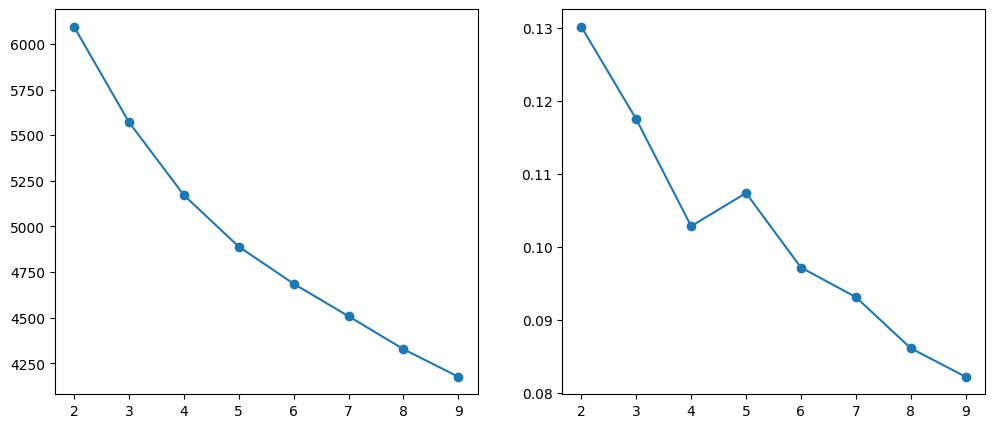

In [73]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(k_range, inertia, "o-")
plt.subplot(1,2,2)
plt.plot(k_range, silhouette_scores, "o-")
plt.show()

- 5가 제일 합리적

## Q6. DBSCAN

In [74]:
eps_range = np.arange(0.3, 1.5, 0.1)
eps_range
min_samples_range = [3,5,7,10]
best_silhouette = -1
best_eps = 0
best_min_sampled = 0

In [75]:
for eps in eps_range:
    for min_samples in min_samples_range:
        ## DBSCAN 군집기 설정
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        ## 예측
        dbscan_labels = dbscan.fit_predict(scaler_returns) # -1 : 노이즈, 이거 어떻게 할래?
        # 최소한 클러스터는 1개 이상, 모든 포인트가 -1이 아니였으면 좋겠음 => ⭐핵심
        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0) # -1(노이즈)이 하나라도 포함되어 있으면 빼겠다는 거임
        # 답안이 없는데 노이즈가 어떻게 있니..
        if n_clusters > 1 and np.sum(dbscan_labels != -1) > 10: # > 10 : 이건 내가 정하는 거, -1이 아닌게 최소 10개는 넘어야지
            non_noise_idx = dbscan_labels != -1 # 일단 안전빵으로 또 걸러
            if np.sum(non_noise_idx) > 1:
                score = silhouette_score(scaler_returns[non_noise_idx], dbscan_labels[non_noise_idx]) # 노이즈 아닌 애들만
                if score > best_silhouette : # min max 알고리즘
                    best_silhouette = score
                    best_eps = eps
                    best_min_sampled = min_samples

In [76]:
print(best_silhouette, best_eps, best_min_sampled)

0.3520712827086478 0.5 3


In [77]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(scaler_returns)

In [78]:
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(scaler_returns)

In [79]:
pca = PCA(n_components=2)
pca_component = pca.fit_transform(scaler_returns)

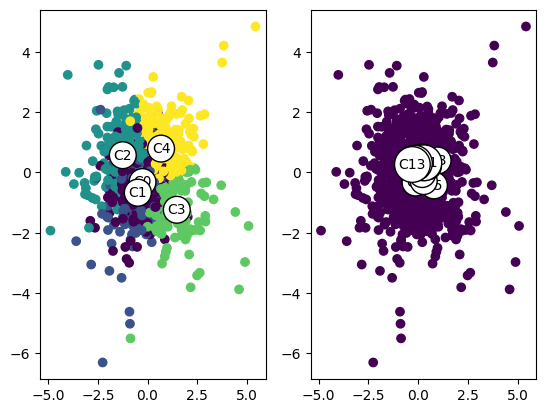

In [80]:
plt.subplot(1,2,1)
plt.scatter(pca_component[:,0], pca_component[:,1], c=kmeans_labels, cmap='viridis')
for i in range(5):
    mask = kmeans_labels == i
    center = np.mean(pca_component[mask], axis=0)
    plt.annotate(
        f'C{i}',
        xy = center,
        ha="center",
        va="center",
        bbox = dict(boxstyle='circle', fc='white', ec='black')
    )
plt.subplot(1,2,2)
plt.scatter(pca_component[:,0], pca_component[:,1], c=dbscan_labels, cmap='viridis')
for i in set(dbscan_labels):
    if i != -1:
        mask = dbscan_labels == i
        center = np.mean(pca_component[mask], axis=0)
        plt.annotate(
            f'C{i}',
            xy = center,
            ha="center",
            va="center",
            bbox = dict(boxstyle='circle', fc='white', ec='black')
    )

- pca로 두개로 분리
- 스캐터로 찍을 때 label에 맞춰서 찍음

## 군집 분류 해석

In [81]:
returns_with_labels = returns.copy()
returns_with_labels["KMeans"] = kmeans_labels
returns_with_labels["DBSCAN"] = dbscan_labels

In [ ]:
returns_with_labels.groupby("KMeans").mean() # 백 테스팅 : 기존 데이터에서 그룹에다가 가격을 적용시켜서 뒤 -> 앞으로 해당 데이터를 곱해서 수익률을...

,KOSPI,S&P 500,Gold,Oil(WTI),US 10Y Bond,KRW/USD,JPY/USD,DBSCAN
KMeans,,,,,,,,
0,0.003464,0.001055,-0.006447,0.004857,-0.002849,-0.001537,-0.000768,-0.546828
1,-0.003564,-0.006978,-0.000699,-0.030496,0.002635,0.000860,0.000752,-1.000000
2,-0.008916,-0.003101,-0.001694,0.003263,-0.001979,0.005870,0.005400,-0.870813
3,0.001312,-0.001022,0.004888,-0.000715,0.002041,-0.006703,-0.008737,-0.910448
4,0.003952,0.006814,0.007274,0.011959,0.001062,0.000623,0.001344,-0.514451


In [83]:
risk_free_rate = 0.02 / 252 # 연 2% 무위험 이자율 / 1년 워킹데이 252일

In [89]:
def calculate_sharpe_ratio(returns_df, risk_free_rate=risk_free_rate, period=252): # 샤프비율
    # returns - risk_free_rate : 판다스에서는 가능 (일반 파이썬, 넘파이는 안 됨)
    excess_returns = returns_df - risk_free_rate
    mean_excess_returns = excess_returns.mean() * period
    std_dev = returns_df.std() * np.sqrt(period)
    return mean_excess_returns / std_dev

In [90]:
KMeans_sharpe_ratios = {}
for cluster in range(5):
    cluster_returns = returns_with_labels[returns_with_labels['KMeans'] == cluster].drop(["KMeans", "DBSCAN"], axis=1) # 필터링
    sharpe_ratios = calculate_sharpe_ratio(cluster_returns)
    KMeans_sharpe_ratios[cluster] = sharpe_ratios

In [91]:
sharpe_df = pd.DataFrame(KMeans_sharpe_ratios)
sharpe_df

,0,1,2,3,4
KOSPI,5.775269,-5.422850,-12.996984,1.550186,6.249705
S&P 500,1.694235,-9.101540,-5.367742,-1.874186,10.641221
Gold,-12.445096,-1.348436,-3.394389,9.674703,17.276710
Oil(WTI),4.118623,-20.827990,2.686658,-0.676243,9.419849
US 10Y Bond,-16.078890,11.833198,-9.151028,8.438936,4.823254
KRW/USD,-5.865286,2.694839,19.984248,-18.116128,2.041768
JPY/USD,-3.319237,2.191920,15.994491,-24.350169,4.883377


데이터가 정확한가? 하지만 인덱스 4번 cluster가 가장 합리적이다.

In [92]:
sharpe_df.mean()

0   -3.731483
1   -2.854408
2    1.107893
3   -3.621843
4    7.905126
dtype: float64

DBSCAN 단점 : 그룹을 정할 수 없다
